# 04 Fair-Play Model Comparison (Dataset P)

This notebook runs a **single, fair protocol** for all candidate models on dataset `P`:

- same dataset and split logic
- same horizons (`1..12`)
- same evaluation metrics (`WAPE`, `RMSE`, `Bias`, `MASE_mean`, `wQL50`)
- same script path and output folder

Candidate models:

- Classical: `ETS`, `ARIMA`, `SARIMA`
- Tree/boosting: `XGBOOST`, `CATBOOST`, `LIGHTGBM`, `RANDOM_FOREST`


In [1]:
from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling')
SCRIPT = ROOT / 'scripts' / 'train_and_save_models.py'
REPORTS_DIR = ROOT / 'outputs' / 'reports'

assert SCRIPT.exists(), f'Missing script: {SCRIPT}'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print('ROOT:', ROOT)
print('SCRIPT:', SCRIPT)
print('REPORTS_DIR:', REPORTS_DIR)

In [2]:
TAG = 'portable_fair_play'
DATASETS = ['P']
CLASSICAL_MODELS = ['ETS', 'ARIMA', 'SARIMA']
BOOSTING_MODELS = ['XGBOOST', 'CATBOOST', 'LIGHTGBM', 'RANDOM_FOREST']
HORIZONS = '1,2,3,4,5,6,7,8,9,10,11,12'
FEATURE_PROFILE = 'full'

cmd = [
    sys.executable,
    str(SCRIPT),
    '--datasets', *DATASETS,
    '--classical-models', *CLASSICAL_MODELS,
    '--boosting-models', *BOOSTING_MODELS,
    '--horizons', HORIZONS,
    '--feature-profile', FEATURE_PROFILE,
    '--tag', TAG,
]
print('RUNNING:', ' '.join(cmd))

In [3]:
subprocess.run(cmd, check=True)

CompletedProcess(args=['/opt/anaconda3/envs/dashboard-project/bin/python', '/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling/scripts/train_and_save_models.py', '--datasets', 'P', '--classical-models', 'ETS', 'ARIMA', 'SARIMA', '--boosting-models', 'XGBOOST', 'CATBOOST', 'LIGHTGBM', 'RANDOM_FOREST', '--horizons', '1,2,3,4,5,6,7,8,9,10,11,12', '--feature-profile', 'full', '--tag', 'portable_fair_play'], returncode=0)

In [4]:
metrics_path = REPORTS_DIR / f'{TAG}_p_metrics.csv'
leaderboard_path = REPORTS_DIR / f'{TAG}_leaderboard.csv'

assert metrics_path.exists(), f'Missing metrics file: {metrics_path}'
assert leaderboard_path.exists(), f'Missing leaderboard file: {leaderboard_path}'

metrics = pd.read_csv(metrics_path)
leaderboard = pd.read_csv(leaderboard_path)

print('metrics rows:', len(metrics))
print('leaderboard rows:', len(leaderboard))
leaderboard

,dataset,model,split,horizon,n_obs,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate
0,P,ARIMA,test,0,3456,0.269123,2.745101e+03,60.651965,0.837422,245.811422,0.416377
1,P,ETS,test,0,3456,0.279660,2.891550e+03,61.659312,0.947901,255.434896,0.427662
2,P,RANDOM_FOREST,test,0,41472,0.297371,2.978164e+03,161.122662,0.952498,271.612522,0.374445
3,P,CATBOOST,test,0,41472,0.320995,2.971725e+03,112.331404,7.850909,293.190011,0.310836
4,P,XGBOOST,test,0,41472,0.321966,3.190205e+03,167.418547,1.792354,294.076896,0.352021
5,P,LIGHTGBM,test,0,41472,0.531594,4.446457e+03,266.395385,1.471762,485.546621,0.397304
6,P,SARIMA,test,0,3456,27.073855,2.493514e+06,48738.717469,1124.788645,24728.664258,0.424190


In [5]:
test_overall = (
    metrics[(metrics['split'] == 'test') & (metrics['horizon'] == 0)]
    .copy()
    .sort_values(['WAPE', 'MASE_mean', 'RMSE'])
    .reset_index(drop=True)
)
cols = ['dataset', 'model', 'WAPE', 'RMSE', 'Bias', 'MASE_mean', 'wQL50', 'under_forecast_rate']
test_overall[cols]

,dataset,model,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate
0,P,ARIMA,0.269123,2.745101e+03,60.651965,0.837422,245.811422,0.416377
1,P,ETS,0.279660,2.891550e+03,61.659312,0.947901,255.434896,0.427662
2,P,RANDOM_FOREST,0.297371,2.978164e+03,161.122662,0.952498,271.612522,0.374445
3,P,CATBOOST,0.320995,2.971725e+03,112.331404,7.850909,293.190011,0.310836
4,P,XGBOOST,0.321966,3.190205e+03,167.418547,1.792354,294.076896,0.352021
5,P,LIGHTGBM,0.531594,4.446457e+03,266.395385,1.471762,485.546621,0.397304
6,P,SARIMA,27.073855,2.493514e+06,48738.717469,1124.788645,24728.664258,0.424190


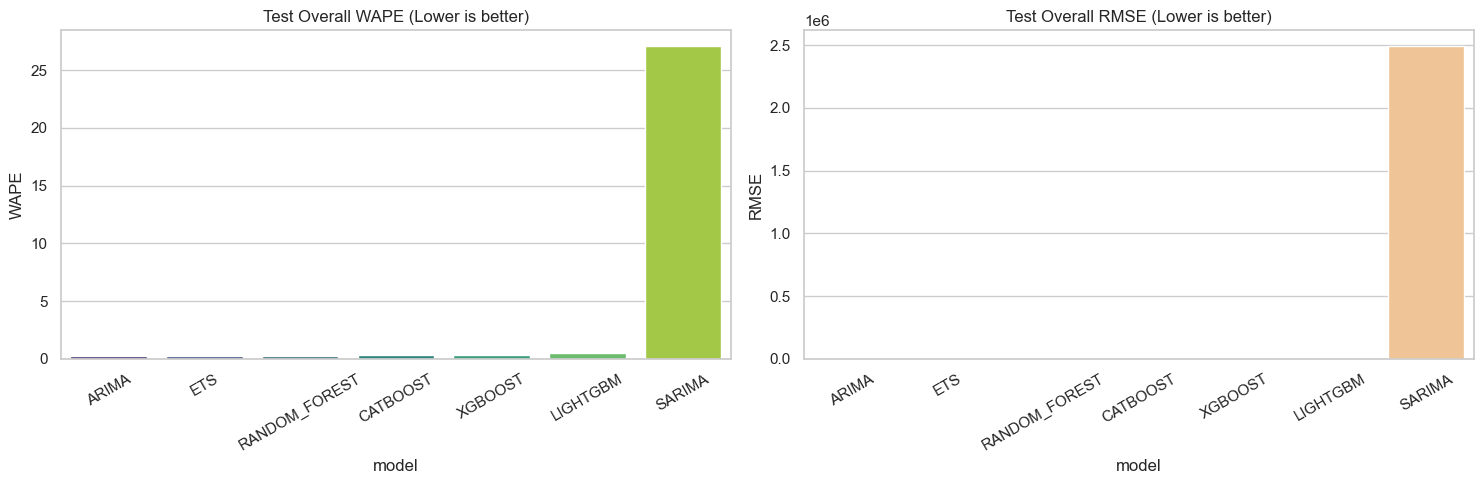

In [6]:
sns.set_theme(style='whitegrid')
plot_df = test_overall.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=plot_df, x='model', y='WAPE', ax=axes[0], palette='viridis')
axes[0].set_title('Test Overall WAPE (Lower is better)')
axes[0].tick_params(axis='x', rotation=30)

sns.barplot(data=plot_df, x='model', y='RMSE', ax=axes[1], palette='magma')
axes[1].set_title('Test Overall RMSE (Lower is better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

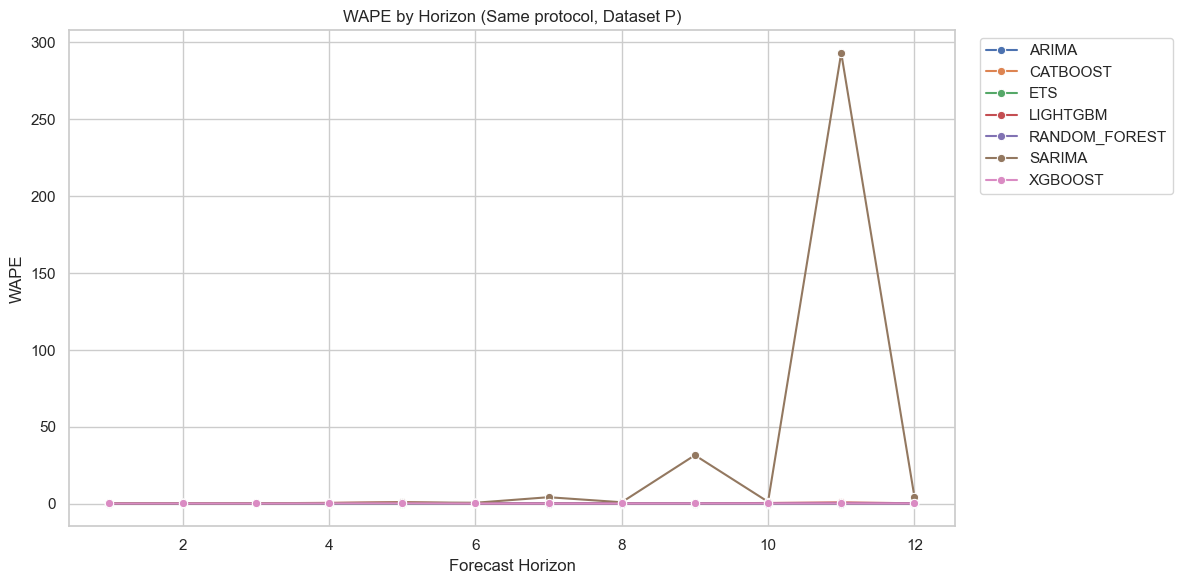

In [7]:
horiz = (
    metrics[(metrics['split'] == 'test') & (metrics['horizon'] > 0)]
    .copy()
    .sort_values(['model', 'horizon'])
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=horiz, x='horizon', y='WAPE', hue='model', marker='o')
plt.title('WAPE by Horizon (Same protocol, Dataset P)')
plt.xlabel('Forecast Horizon')
plt.ylabel('WAPE')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [8]:
winner = test_overall.iloc[0]
winner_model = winner['model']
winner_wape = float(winner['WAPE'])
winner_mase = float(winner['MASE_mean'])

rows = []
for _, row in test_overall.iterrows():
    model = row['model']
    reasons = []
    if model != winner_model:
        if float(row['WAPE']) > winner_wape:
            reasons.append(f"higher WAPE ({row['WAPE']:.6f} > {winner_wape:.6f})")
        if float(row['RMSE']) > float(winner['RMSE']):
            reasons.append('higher RMSE')
        if abs(float(row['Bias'])) > abs(float(winner['Bias'])):
            reasons.append('higher absolute bias')
        if float(row['MASE_mean']) > winner_mase:
            reasons.append('higher MASE_mean')
    status = 'WINNER' if model == winner_model else 'REJECTED'
    rows.append({
        'model': model,
        'status': status,
        'reason': 'best overall on fair protocol' if status == 'WINNER' else '; '.join(reasons) if reasons else 'not top ranked',
    })

decision = pd.DataFrame(rows)
decision

,model,status,reason
0,ARIMA,WINNER,best overall on fair protocol
1,ETS,REJECTED,higher WAPE (0.279660 > 0.269123); higher RMSE...
2,RANDOM_FOREST,REJECTED,higher WAPE (0.297371 > 0.269123); higher RMSE...
3,CATBOOST,REJECTED,higher WAPE (0.320995 > 0.269123); higher RMSE...
4,XGBOOST,REJECTED,higher WAPE (0.321966 > 0.269123); higher RMSE...
5,LIGHTGBM,REJECTED,higher WAPE (0.531594 > 0.269123); higher RMSE...
6,SARIMA,REJECTED,higher WAPE (27.073855 > 0.269123); higher RMS...


In [9]:
print('CHAMPION MODEL (fair-play on P):', winner_model)
print('Champion WAPE:', round(float(winner['WAPE']), 6))
print('Champion RMSE:', round(float(winner['RMSE']), 3))
print('Champion Bias:', round(float(winner['Bias']), 3))
print('Champion MASE_mean:', round(float(winner['MASE_mean']), 6))

In [10]:
import subprocess
import sys
from pathlib import Path

ROOT = Path('/Users/k.e.oshada/Documents/OptiWMS')
ARCHIVE_SCRIPT = ROOT / 'Ai miroservices' / 'modeling' / 'scripts' / 'archive_leaderboard_round.py'
REPORTS_DIR = ROOT / 'Ai miroservices' / 'modeling' / 'outputs' / 'reports'
LOG_PATH = ROOT / 'docs' / 'ai' / 'FORECAST_LEADERBOARD_ROUND_LOG.md'

note = f"04_fair_play_model_comparison rerun; winner={winner_model}"
cmd = [
    sys.executable,
    str(ARCHIVE_SCRIPT),
    '--reports-dir', str(REPORTS_DIR),
    '--log-path', str(LOG_PATH),
    '--note', note,
]
print('RUNNING:', ' '.join(cmd))
result = subprocess.run(cmd, check=True, text=True, capture_output=True)
print(result.stdout)

## PV2 Improvement Experiment

Run a focused PV2 CATBOOST tuning pass and inspect whether the best candidate can meet the deployment gate. This section reuses the modeling scripts and writes fresh reports under `outputs/reports`.

In [1]:
from pathlib import Path
import subprocess
import sys

PV2_ROOT = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling')
PV2_SCRIPT = PV2_ROOT / 'scripts' / 'tune_pv2_catboost.py'
PV2_REPORTS = PV2_ROOT / 'outputs' / 'reports'

assert PV2_SCRIPT.exists(), f'Missing script: {PV2_SCRIPT}'
print('PV2_SCRIPT:', PV2_SCRIPT)
print('PV2_REPORTS:', PV2_REPORTS)

pv2_cmd = [
    sys.executable,
    str(PV2_SCRIPT),
    '--dataset', 'PV2',
    '--feature-profile', 'lags_roll_seasonal_category',
    '--max-trials', '8',
    '--horizons', '1,2,3,4,5,6,7,8,9,10,11,12',
    '--tune-horizons', '1,3,6,12',
    '--tag', 'pv2_notebook_tuned',
]

print('RUNNING:', ' '.join(pv2_cmd))
result = subprocess.run(pv2_cmd, check=True, text=True, capture_output=True)
print(result.stdout)
if result.stderr:
    print(result.stderr)

In [2]:
import pandas as pd

pv2_leaderboard = PV2_REPORTS / 'pv2_notebook_tuned_leaderboard.csv'
pv2_metrics = PV2_REPORTS / 'pv2_notebook_tuned_pv2_metrics.csv'

assert pv2_leaderboard.exists(), f'Missing leaderboard: {pv2_leaderboard}'
assert pv2_metrics.exists(), f'Missing metrics: {pv2_metrics}'

leaderboard_df = pd.read_csv(pv2_leaderboard)
metrics_df = pd.read_csv(pv2_metrics)

pv2_test0 = metrics_df[(metrics_df['split'] == 'test') & (metrics_df['horizon'] == 0)].copy()
pv2_test0 = pv2_test0.sort_values(['WAPE', 'MASE_mean', 'RMSE']).reset_index(drop=True)

display(pv2_test0[['dataset', 'model', 'WAPE', 'RMSE', 'Bias', 'MASE_mean', 'wQL50', 'under_forecast_rate']])
print('Leaderboard file:', pv2_leaderboard)
print('Metrics file:', pv2_metrics)
if not pv2_test0.empty:
    row = pv2_test0.iloc[0]
    print('Gate candidate WAPE:', round(float(row['WAPE']), 6))
    print('Gate candidate status:', 'PASS' if float(row['WAPE']) <= 0.135 else 'FAIL')

,dataset,model,WAPE,RMSE,Bias,MASE_mean,wQL50,under_forecast_rate
0,PV2,CATBOOST,0.208748,2437.574624,-125.976057,18.648607,225.694778,0.457563


## PV2 Challenger Sweep (Enterprise)

This run evaluates multiple challenger configurations for dataset `PV2` and ranks them by `test` overall (`horizon=0`) WAPE.

Gate target: `WAPE <= 0.135`.

In [3]:
from pathlib import Path
import subprocess
import sys
import pandas as pd

PV2_ROOT = Path('/Users/k.e.oshada/Documents/OptiWMS/Ai miroservices/modeling')
TRAIN_SCRIPT = PV2_ROOT / 'scripts' / 'train_and_save_models.py'
REPORTS_DIR = PV2_ROOT / 'outputs' / 'reports'

profiles = ['lags_roll_seasonal_category', 'full']
boosting_models = ['XGBOOST', 'CATBOOST', 'LIGHTGBM', 'RANDOM_FOREST']
tags = []

for profile in profiles:
    tag = f'pv2_challenger_{profile}'
    tags.append(tag)
    cmd = [
        sys.executable, str(TRAIN_SCRIPT),
        '--datasets', 'PV2',
        '--skip-classical',
        '--boosting-models', *boosting_models,
        '--horizons', '1,2,3,4,5,6,7,8,9,10,11,12',
        '--feature-profile', profile,
        '--tag', tag,
    ]
    print('RUNNING:', ' '.join(cmd))
    run = subprocess.run(cmd, check=True, text=True, capture_output=True)
    print(run.stdout)
    if run.stderr:
        print(run.stderr)

rows = []
for tag in tags:
    lb_path = REPORTS_DIR / f'{tag}_leaderboard.csv'
    if not lb_path.exists():
        continue
    lb = pd.read_csv(lb_path)
    m = lb[(lb['dataset'] == 'PV2') & (lb['split'] == 'test') & (lb['horizon'] == 0)].copy()
    m['tag'] = tag
    rows.append(m)

challenger = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
assert not challenger.empty, 'No challenger leaderboard rows found.'
challenger['gate_pass_wape'] = challenger['WAPE'] <= 0.135
challenger = challenger.sort_values(['WAPE', 'MASE_mean', 'RMSE']).reset_index(drop=True)
challenger[['tag', 'dataset', 'model', 'WAPE', 'RMSE', 'Bias', 'MASE_mean', 'under_forecast_rate', 'gate_pass_wape']]

,tag,dataset,model,WAPE,RMSE,Bias,MASE_mean,under_forecast_rate,gate_pass_wape
0,pv2_challenger_lags_roll_seasonal_category,PV2,CATBOOST,0.193944,465.607994,-31.215974,0.916691,0.488715,False
1,pv2_challenger_full,PV2,CATBOOST,0.193944,465.607994,-31.215974,0.916691,0.488715,False
2,pv2_challenger_lags_roll_seasonal_category,PV2,RANDOM_FOREST,0.204461,492.137717,-14.700445,0.959912,0.477286,False
3,pv2_challenger_full,PV2,RANDOM_FOREST,0.204461,492.137717,-14.700445,0.959912,0.477286,False
4,pv2_challenger_lags_roll_seasonal_category,PV2,XGBOOST,0.207437,496.854692,-20.958560,0.972814,0.493128,False
5,pv2_challenger_full,PV2,XGBOOST,0.207437,496.854692,-20.958560,0.972814,0.493128,False
6,pv2_challenger_lags_roll_seasonal_category,PV2,LIGHTGBM,0.214878,512.654683,-15.626508,1.013045,0.486834,False
7,pv2_challenger_full,PV2,LIGHTGBM,0.214878,512.654683,-15.626508,1.013045,0.486834,False
